# House Price Prediction using Machine Learning
### Objective:
#### Predict house prices using various regression models and compare their performance.



## 1. Import Libraries
### Purpose: 
I import all the library required for this project

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [128]:
Data = pd.read_csv("Housing-project-train-data.csv")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [129]:
Data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,127,120,RL,NaN,4928,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NPkVill,Norm,Norm,TwnhsE,1Story,6,5,1976,1976,Gable,CompShg,Plywood,Plywood,NaN,0.0,TA,TA,CBlock,Gd,TA,No,ALQ,120,Unf,0,958,1078,GasA,TA,Y,SBrkr,958,0,0,958,0,0,2,0,2,1,TA,5,Typ,1,TA,Attchd,1977.0,RFn,2,440,TA,TA,Y,0,205,0,0,0,0,NaN,NaN,NaN,0,2,2007,WD,Normal,128000
1,889,20,RL,95.0,15865,Pave,NaN,IR1,Lvl,AllPub,Inside,Mod,NAmes,Norm,Norm,1Fam,1Story,8,6,1970,1970,Flat,Tar&Grv,Wd Sdng,Wd Sdng,NaN,0.0,Gd,Gd,PConc,TA,Gd,Gd,ALQ,351,Rec,823,1043,2217,GasA,Ex,Y,SBrkr,2217,0,0,2217,1,0,2,0,4,1,Gd,8,Typ,1,TA,Attchd,1970.0,Unf,2,621,TA,TA,Y,81,207,0,0,224,0,NaN,NaN,NaN,0,10,2007,WD,Normal,268000
2,793,60,RL,92.0,9920,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,NoRidge,Norm,Norm,1Fam,2Story,7,5,1996,1997,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,Gd,TA,PConc,Gd,TA,Av,GLQ,862,Unf,0,255,1117,GasA,Ex,Y,SBrkr,1127,886,0,2013,1,0,2,1,3,1,TA,8,Typ,1,TA,Attchd,1997.0,Unf,2,455,TA,TA,Y,180,130,0,0,0,0,NaN,NaN,NaN,0,6,2007,WD,Normal,269790
3,110,20,RL,105.0,11751,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1977,1977,Hip,CompShg,Plywood,Plywood,BrkFace,480.0,TA,TA,CBlock,Gd,TA,No,BLQ,705,Unf,0,1139,1844,GasA,Ex,Y,SBrkr,1844,0,0,1844,0,0,2,0,3,1,TA,7,Typ,1,TA,Attchd,1977.0,RFn,2,546,TA,TA,Y,0,122,0,0,0,0,NaN,MnPrv,NaN,0,1,2010,COD,Normal,190000
4,422,20,RL,NaN,16635,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,7,1977,2000,Gable,CompShg,CemntBd,CmentBd,Stone,126.0,Gd,TA,CBlock,Gd,TA,No,ALQ,1246,Unf,0,356,1602,GasA,Gd,Y,SBrkr,1602,0,0,1602,0,1,2,0,3,1,Gd,8,Typ,1,TA,Attchd,1977.0,Fin,2,529,TA,TA,Y,240,0,0,0,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal,215000


## 3. Understand the Dataset

### Purpose:
Performing basic activities on data such as its shape, columns and much more

In [130]:
Data.shape

(1168, 81)

In [131]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    954 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          77 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallC

In [132]:
Data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1168.000000,1168.000000,954.00000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1161.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1104.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,724.136130,56.767979,70.98847,10484.749144,6.104452,5.595890,1970.930651,1984.758562,102.310078,444.726027,46.647260,569.721747,1061.095034,1169.860445,348.826199,6.380137,1525.066781,0.425514,0.055651,1.562500,0.388699,2.884418,1.045377,6.542808,0.617295,1978.193841,1.776541,476.860445,96.206336,46.559932,23.015411,3.639555,15.051370,3.448630,47.315068,6.344178,2007.804795,181477.005993
std,416.159877,41.940650,24.82875,8957.442311,1.390153,1.124343,30.145255,20.785185,182.595606,462.664785,163.520016,449.375525,442.272249,391.161983,439.696370,50.892844,528.042957,0.521615,0.236699,0.551882,0.504929,0.817229,0.216292,1.598484,0.650575,24.890704,0.745554,214.466769,126.158988,66.381023,63.191089,29.088867,55.080816,44.896939,543.264432,2.686352,1.329738,79105.586863
min,1.000000,20.000000,21.00000,1300.000000,1.000000,1.000000,1875.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,360.500000,20.000000,60.00000,7621.500000,5.000000,5.000000,1954.000000,1966.000000,0.000000,0.000000,0.000000,216.000000,799.000000,892.000000,0.000000,0.000000,1143.250000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,338.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,130375.000000
50%,714.500000,50.000000,70.00000,9522.500000,6.000000,5.000000,1972.000000,1993.000000,0.000000,385.500000,0.000000,474.000000,1005.500000,1096.500000,0.000000,0.000000,1468.500000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163995.000000
75%,1079.500000,70.000000,80.00000,11515.500000,7.000000,6.000000,2000.000000,2004.000000,160.000000,714.500000,0.000000,816.000000,1291.500000,1392.000000,729.000000,0.000000,1795.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,171.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,215000.000000
max,1460.000000,190.000000,313.00000,164660.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [133]:
Data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [134]:
Data.isnull().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       214
LotArea             0
Street              0
Alley            1091
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        703
MasVnrArea          7
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           30
BsmtCond           30
BsmtExposure       31
BsmtFinType1       30
BsmtFinSF1          0
BsmtFinType2       31
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          0
1stFlrSF            0
2ndFlrSF            0
LowQualFin

# 5. Performing EDA
## Purpose:
I compare basic attributes of data with each other

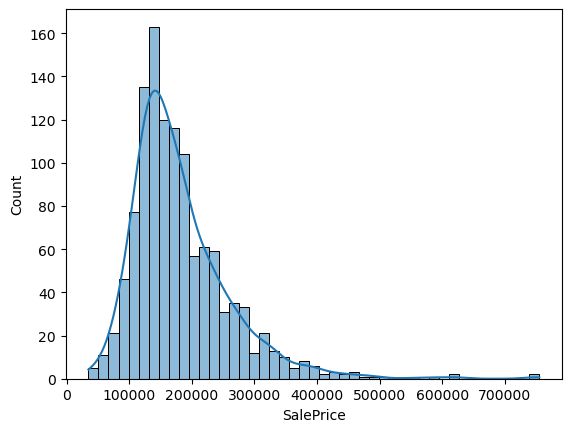

In [135]:
sns.histplot(Data['SalePrice'],kde=True)
plt.show()

### Observation
The saleprice distribution is right-skewed, indicating that most houses are moderately priced while a few expensive houses increase the upper tail.

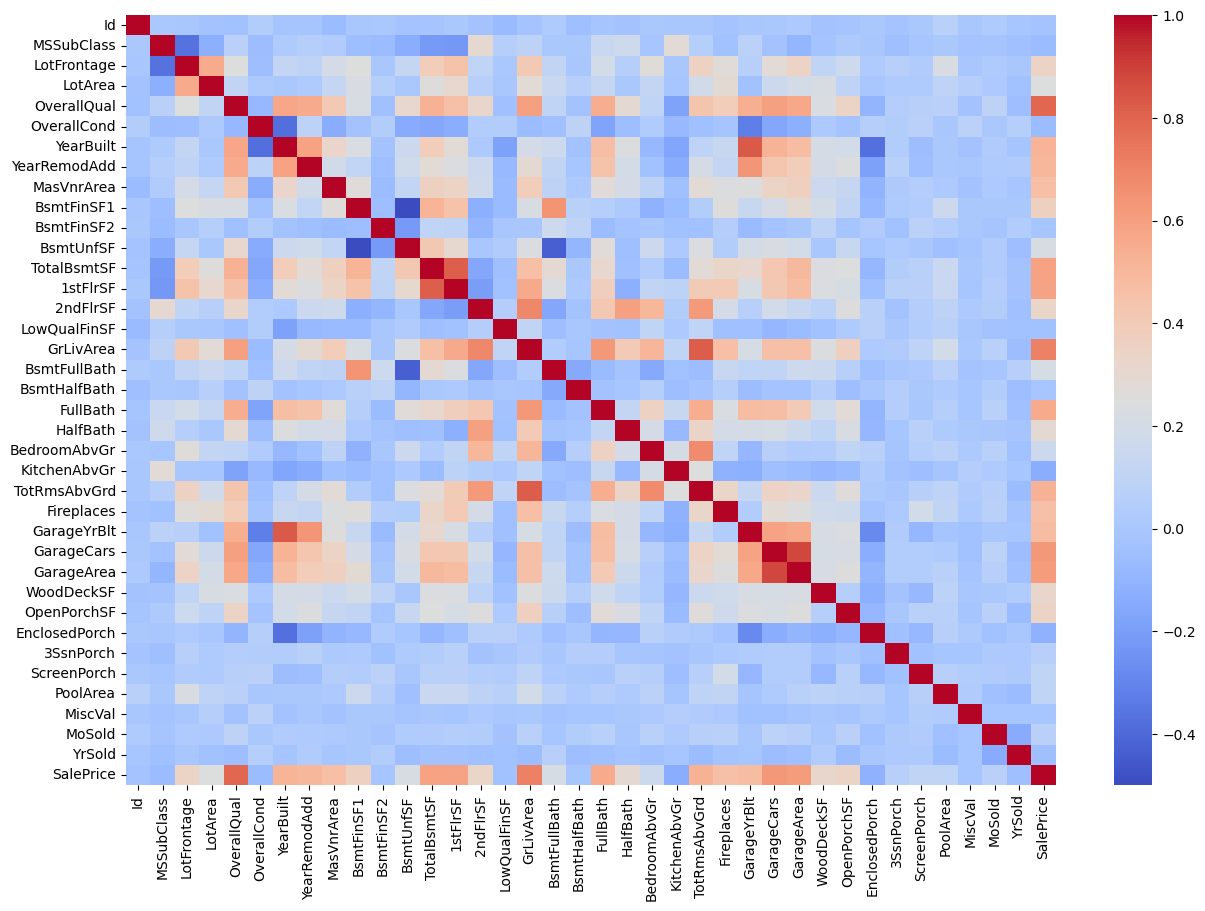

In [136]:
plt.figure(figsize=(15,10))
sns.heatmap(Data.corr(numeric_only=True), cmap='coolwarm')
plt.show()

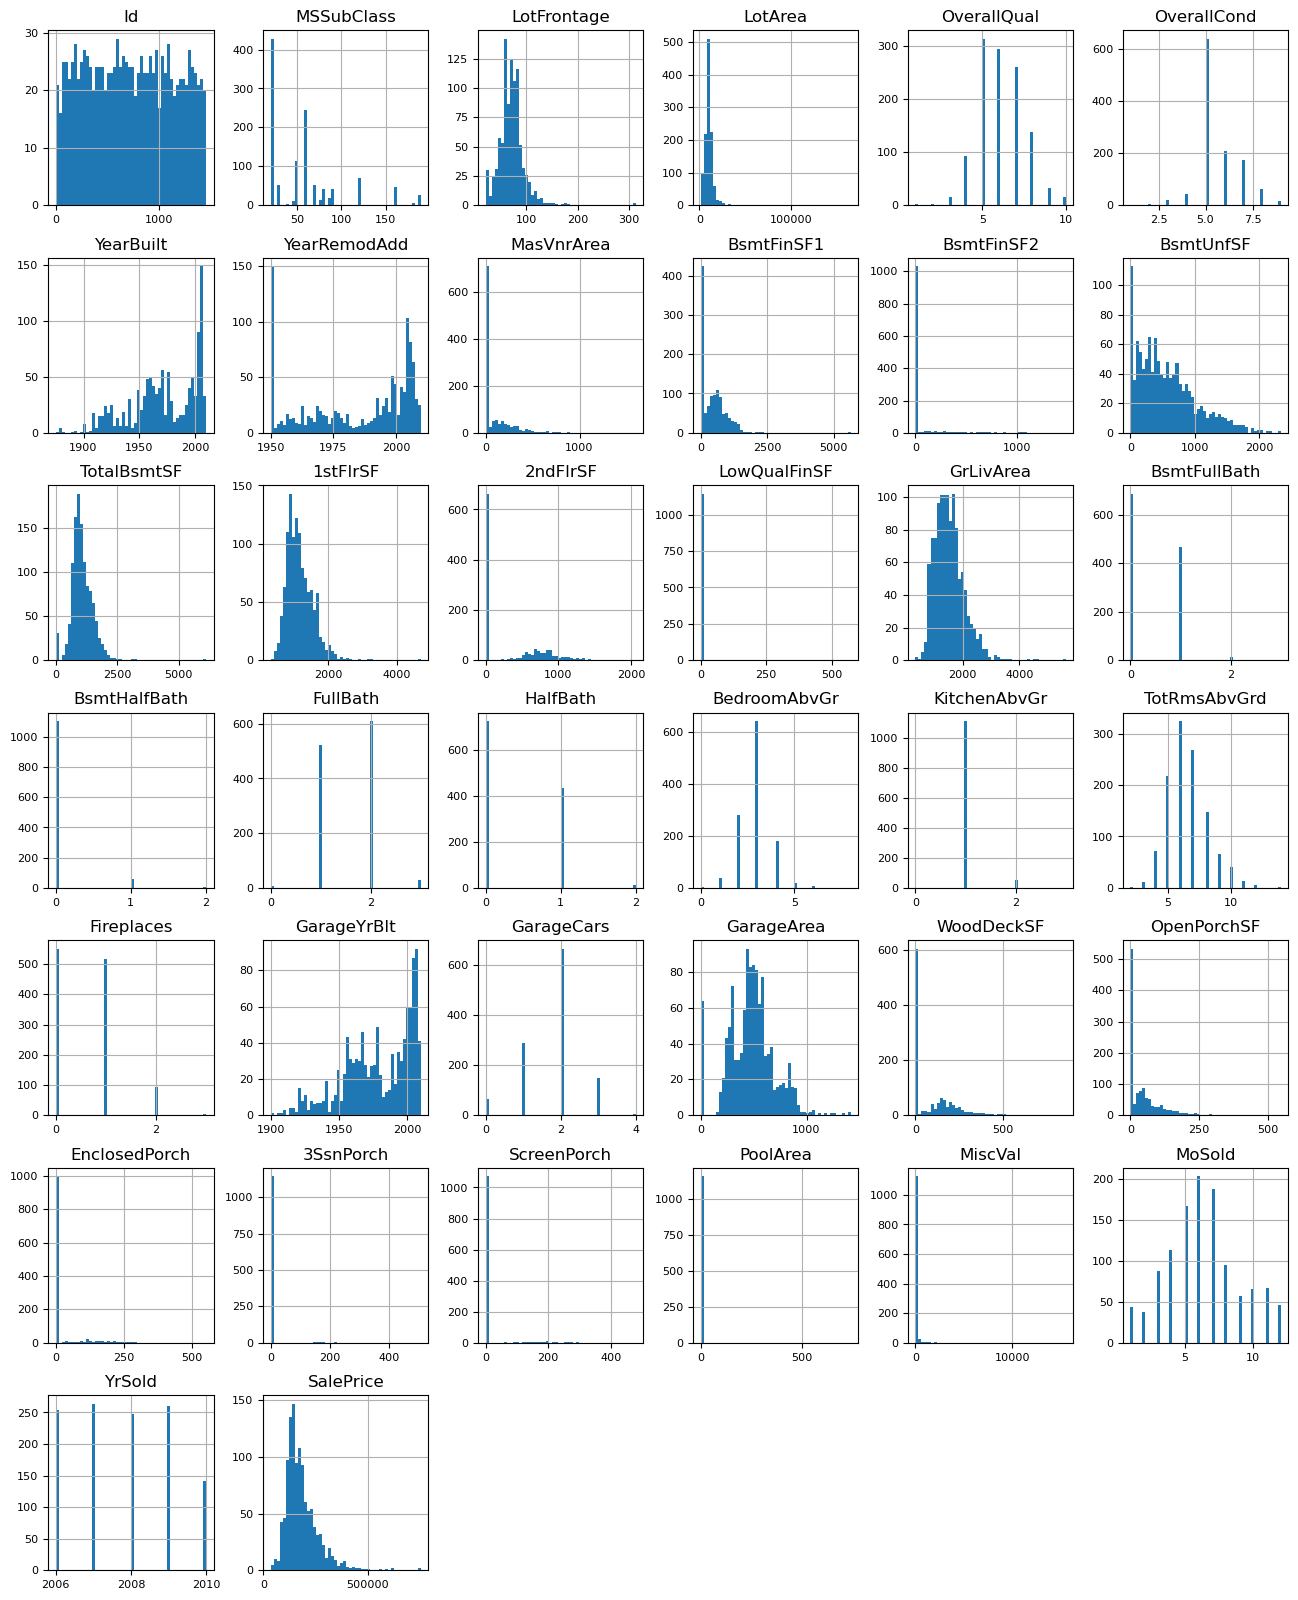

In [137]:
Data.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

### Observation
I tried to plot a histogram for each attribute present in data

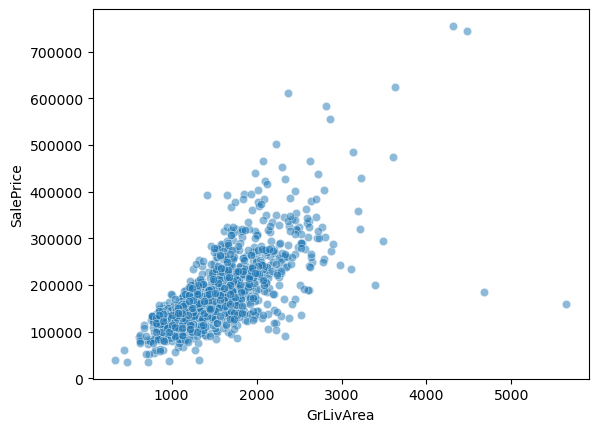

In [138]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=Data,alpha=0.5)
plt.show()

### Observation:
Here the graph signifies that as the living area of house is increasing, saleprice of house is also increasing

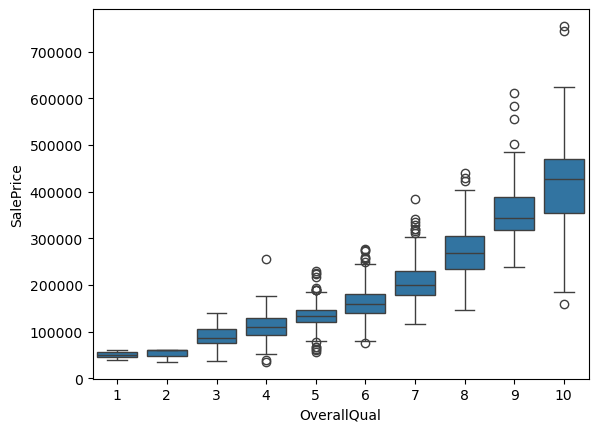

In [139]:
sns.boxplot(x='OverallQual',y='SalePrice',data=Data)
plt.show()

### Observation:
The graph signifies that as the overall quality of house is increasing, saleprice of house is also increasing

## 5. Feature Engineering
### Purpose:
Adding new columns which would help our model to analyse data better

In [140]:
Data['TotalSF'] =Data['TotalBsmtSF']+Data['1stFlrSF']+Data['2ndFlrSF']
Data['TotalBath']=Data['FullBath']+0.5*Data['HalfBath']+Data['BsmtFullBath']+0.5*Data['BsmtHalfBath']
Data['HouseAge']=Data['YrSold']-Data['YearBuilt']
Data['TotalPorchSF']=Data['OpenPorchSF']+Data['EnclosedPorch']+Data['3SsnPorch']+Data['ScreenPorch']
Data['RemodelAge']=Data['YrSold']-Data['YearRemodAdd']
Data['QualityScore']=Data['OverallQual']*Data['OverallCond']

## 6. Data Cleaning
### Purpose:
Here, I used the median to replace missing values in numerical (integer and float) columns and the mode to fill missing values in categorical (object) columns.

In [141]:
num_cols =Data.select_dtypes(include=['int64','float64']).columns
cat_cols =Data.select_dtypes(include='object').columns
if len(num_cols) > 0:
    num_imputer=SimpleImputer(strategy='median')
    Data[num_cols]=num_imputer.fit_transform(Data[num_cols])

if len(cat_cols) > 0:
    cat_imputer=SimpleImputer(strategy='most_frequent')
    Data[cat_cols]=cat_imputer.fit_transform(Data[cat_cols])

Here, I used the median to replace missing values in numerical (integer and float) columns and the mode to fill missing values in categorical (object) columns.

## 7. Encode Categorical Variables

### Purpose:
I converted categorical features into numerical format using One-Hot Encoding so machine learning models can process them.

In [142]:
Data =pd.get_dummies(Data, drop_first=True)

In [143]:
bool_cols =Data.select_dtypes(include='bool').columns
Data[bool_cols]=Data[bool_cols].astype(int)

## 8. Split Features and Target

### Purpose:
I separate the independent variables (X) from the target variable (SalePrice).

In [144]:
X = Data.drop('SalePrice', axis=1)
y = np.log1p(Data['SalePrice'])

I noticed that the target values were not normally distributed, so I applied a log transformation to reduce skewness and help the model learn better.

## 9. Train-Test Split

### Purpose:
Divide the dataset into training and testing sets to evaluate model performance on unseen data.

In [145]:
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.2,random_state=42)

## 10. Feature Scaling 

### Purpose: 
Standardize numerical features for models that are sensitive to feature scales.

In [146]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 11. Linear Regression

### Purpose:
Train a baseline regression model and evaluate its performance using R², MSE, and RMSE.

In [147]:
model1=LinearRegression()
model1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [148]:
y1_pred=model1.predict(X_test)

In [149]:
lr_mse = mean_squared_error(y_test, y1_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y1_pred)

print("lr_MSE :",lr_mse)
print("lr_RMSE :",lr_rmse )
print("lr_R² :",lr_r2 )

lr_MSE : 0.12857474522205076
lr_RMSE : 0.3585732076188219
lr_R² : 0.1951918546516197


In [150]:
print(model1.score(X_test, y_test))

0.1951918546516197


## 12. Decision Tree Regressor

### Purpose: 
Train a Decision Tree model and evaluate its performance using R², MSE, and RMSE.

In [151]:
model2=DecisionTreeRegressor(random_state=42)
model2.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [152]:
y2_pred=model2.predict(X_test)

In [153]:
dtr_mse = mean_squared_error(y_test, y2_pred)
dtr_rmse = np.sqrt(dtr_mse)
dtr_r2 = r2_score(y_test, y2_pred)

print("dtr_MSE :",dtr_mse)
print("dtr_RMSE :",dtr_rmse)
print("dtr_R² :",dtr_r2)

dtr_MSE : 0.051707632064026184
dtr_RMSE : 0.22739312228830974
dtr_R² : 0.6763382778636968


## 13. Random Forest Regressor

### Purpose:
Build an ensemble model using multiple decision trees to improve prediction accuracy.

In [154]:
model3=RandomForestRegressor(n_estimators=100,random_state=42)
model3.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [155]:
y3_pred = model3.predict(X_test)

In [156]:
rfr_mse = mean_squared_error(y_test, y3_pred)
rfr_rmse = np.sqrt(rfr_mse)
rfr_r2 = r2_score(y_test, y3_pred)
print("rfr_MSE :", rfr_mse)
print("rfr_RMSE :",rfr_rmse)
print("rfr_R² :", rfr_r2)

rfr_MSE : 0.027610496267714335
rfr_RMSE : 0.1661640643090868
rfr_R² : 0.8271732737639009


## 14. Gradient Boosting Regressor (GBM)

### Purpose:
Train a Gradient Boosting model, which combines weak learners sequentially to improve prediction accuracy.

In [157]:
model4=GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,random_state=42)
model4.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [158]:
y4_pred = model4.predict(X_test)

In [159]:
gbr_mse = mean_squared_error(y_test, y4_pred)
gbr_rmse = np.sqrt(gbr_mse)
gbr_r2 = r2_score(y_test, y4_pred)
print("gbr_MSE :",gbr_mse)
print("gbr_RMSE :",gbr_rmse)
print("gbr_R² :", gbr_r2)

gbr_MSE : 0.0218336220788091
gbr_RMSE : 0.14776204546096774
gbr_R² : 0.8633333718753486


## 15. XGBoost Regressor
### Purpose: 
Train an optimized boosting algorithm and compare its performance with GBM.

In [160]:
model5=XGBRegressor(n_estimators=100,max_depth=4,learning_rate=0.1,random_state=42,n_jobs=-1)
model5.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [161]:
y5_pred = model5.predict(X_test)

In [162]:
xgb_mse = mean_squared_error(y_test, y5_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y5_pred)
print("xgb_MSE :", xgb_mse)
print("xgb_RMSE :",xgb_rmse)
print("xgb_R² :",xgb_r2)

xgb_MSE : 0.022157972050885676
xgb_RMSE : 0.14885554088069974
xgb_R² : 0.861303117030045


## 16. Model Evaluation

### Purpose: Compare all models:

Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)
R² Score


Model having highest R² and lowest Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) will be choosen for prediction

In [163]:
Comparison_table=pd.DataFrame({"Model":["LinearRegression","DecisionTreeRegressor","RandomForestRegressor","GradientBoostingRegressor","XGBRegressor"],
                               "MSE":[lr_mse,dtr_mse,rfr_mse,gbr_mse,xgb_mse],
                               "RMSE":[lr_rmse,dtr_rmse,rfr_rmse,gbr_rmse,xgb_rmse],
                               "R² Score":[lr_r2,dtr_r2,rfr_r2,gbr_r2,xgb_r2],})
Comparison_table

,Model,MSE,RMSE,R² Score
0,LinearRegression,0.128575,0.358573,0.195192
1,DecisionTreeRegressor,0.051708,0.227393,0.676338
2,RandomForestRegressor,0.027610,0.166164,0.827173
3,GradientBoostingRegressor,0.021834,0.147762,0.863333
4,XGBRegressor,0.022158,0.148856,0.861303


In this data above, GradientBoostingRegressor have highest R² and lowest Mean Squared Error (MSE) and Root Mean Squared Error (RMSE),
So I am taking GradientBoostingRegressor as best regressor for our data

## 17. Hyperparameter Tuning

### Purpose:
Hyperparameter tuning is a common technique used to optimize the performance of the selected model.

In [171]:
param_dist = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}
random_search = RandomizedSearchCV(
    estimator=model4,
    param_distributions=param_dist,
    n_iter=30,          
    cv=5,             
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Best Parameters:", random_search.best_params_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.1}
RMSE: 0.15013717437506435
R² Score: 0.8589044987081643


Although hyperparameter tuning was performed, the tuned model achieved a slightly lower R² score than the original Gradient Boosting Regressor. Therefore, the original model (Model 4) was selected as the final model.

In [182]:
best_model=model4

## 18. Predict on Test Dataset
### Purpose:
Apply the same preprocessing to the test dataset and generate house price predictions using the final tuned model.

In [ ]:
Test_Data=pd.read_csv("Housing-project-test-data.csv")
test_id = Test_Data["Id"]

In [ ]:
Test_Data.head()

In [ ]:
Test_Data['TotalSF'] =Test_Data['TotalBsmtSF']+Test_Data['1stFlrSF']+Test_Data['2ndFlrSF']
Test_Data['TotalBath']=Test_Data['FullBath']+0.5*Test_Data['HalfBath']+Test_Data['BsmtFullBath']+0.5*Test_Data['BsmtHalfBath']
Test_Data['HouseAge']=Test_Data['YrSold']-Test_Data['YearBuilt']
Test_Data['TotalPorchSF']=Test_Data['OpenPorchSF']+Test_Data['EnclosedPorch']+Test_Data['3SsnPorch']+Test_Data['ScreenPorch']
Test_Data['RemodelAge']=Test_Data['YrSold']-Test_Data['YearRemodAdd']
Test_Data['QualityScore']=Test_Data['OverallQual']*Test_Data['OverallCond']

The same feature engineering and other techniques applied to the training dataset were also applied to the test dataset to ensure consistency between training and prediction data.

In [186]:
num_cols = Test_Data.select_dtypes(include=['int64','float64']).columns
cat_cols = Test_Data.select_dtypes(include='object').columns
num_cols = num_cols.difference(cat_cols)
num_cols = num_cols.drop_duplicates()
cat_cols = cat_cols.drop_duplicates()
if len(num_cols) > 0:
    valid_num_cols = []
    for col in num_cols:
        if Test_Data[col].notna().sum() > 0:  
            valid_num_cols.append(col)
    if len(valid_num_cols) > 0:
        num_imputer = SimpleImputer(strategy='median')
        imputed_num_data = num_imputer.fit_transform(Test_Data[valid_num_cols])
        Test_Data[valid_num_cols] = imputed_num_data
if len(cat_cols) > 0:
    valid_cat_cols = []
    for col in cat_cols:
        if Test_Data[col].notna().sum() > 0: 
            valid_cat_cols.append(col)
    if len(valid_cat_cols) > 0:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        imputed_cat_data = cat_imputer.fit_transform(Test_Data[valid_cat_cols])
        Test_Data[valid_cat_cols] = imputed_cat_data

In [187]:
Test_Data= pd.get_dummies(Test_Data, drop_first=True)

In [188]:
bool_cols = Test_Data.select_dtypes(include='bool').columns
Test_Data[bool_cols] = Test_Data[bool_cols].astype(int)

In [189]:
X_train = Data.drop("SalePrice", axis=1)
Test_Data = Test_Data.reindex(columns=X_train.columns, fill_value=0)
predictions = best_model.predict(Test_Data)
predictions = np.expm1(predictions)
submission = pd.DataFrame({"Id": test_id,"SalePrice": predictions})

In [190]:
submission.to_csv("submission.csv", index=False)
print(submission)

       Id      SalePrice
0     337  211716.384289
1    1018  205793.667808
2     929  220392.017554
3    1148  224137.413392
4    1227  221372.819535
5     650  228091.963613
6    1453  228694.234397
7     152  230605.540690
8     427  214293.146309
9     776  231346.331961
10     30  209197.429490
11   1425  217084.951606
12    423  229350.304306
13   1185  238798.797078
14    775  218186.944935
15    391  231673.444398
16   1408  220870.298649
17    513  221938.052439
18   1266  231454.748521
19    173  220962.276191
20   1150  224137.413392
21    797  208107.866086
22    137  229304.149451
23    706  233642.864573
24   1377  233327.157249
25   1177  203977.047458
26   1456  240570.878506
27    369  231346.331961
28   1421  242528.266881
29    999  235092.577837
30   1217  231973.572174
31    937  233327.157249
32    769  213856.063487
33    831  227767.564419
34    678  209197.429490
35    574  215392.145244
36    921  215497.822070
37   1292  206913.328825
38   1277  217675.717609


# Conclusion:
From this project I predicted the test housing price of houses by taking GradientBoostingRegressor as best model and applying hyperparameter tuning to it